# US Airlines Tweets

### System setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.metrics import classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay
import re
import itertools


In [2]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Data understanding

In [3]:
# Load data
data = pd.read_csv("Data/Tweets.csv")

### 1.1 Basic understanding

In [4]:
data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Show the classes of the features
print("Unique sentiment classes: ", data["airline_sentiment"].unique(), "\n")
print("Classes for negative reason: ", data["negativereason"].unique(), "\n")
print("The airlines: ", data["airline"].unique(), "\n")
print("Sentiment classes for gold...?: ", data["airline_sentiment_gold"].unique(), "\n")
print("Classes gold for negative reason: ", data["negativereason_gold"].unique(), "\n")
print("Tweet locations:", data["tweet_location"].unique(), "\n")

Unique sentiment classes:  <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str 

Classes for negative reason:  <StringArray>
[                          nan,                  'Bad Flight',
                  'Can't Tell',                 'Late Flight',
      'Customer Service Issue',     'Flight Booking Problems',
                'Lost Luggage', 'Flight Attendant Complaints',
            'Cancelled Flight',             'Damaged Luggage',
                   'longlines']
Length: 11, dtype: str 

The airlines:  <StringArray>
['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Length: 6, dtype: str 

Sentiment classes for gold...?:  <StringArray>
[nan, 'negative', 'neutral', 'positive']
Length: 4, dtype: str 

Classes gold for negative reason:  <StringArray>
[                                         nan,
 'Late Flight\r\nFlight Attendant Complaints',
                'Late Flight\r\nLost Luggage',
                                'Late Flight',
    

In [6]:
print("Shape of the data: ",data.shape, "\n") # shape of the data
print("Columns in the data: \n", data.columns, "\n") # Columnnames
print("Types of the features: \n", data.dtypes) # Data types of the features

Shape of the data:  (14640, 15) 

Columns in the data: 
 Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str') 

Types of the features: 
 tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                

In [7]:
# Describe the numerical features
data.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


### 1.2 Data Quality

In [8]:
# missing values
data.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [9]:
# Duplicates
print("Amount of duplicates in the data:", data.duplicated().sum(), "\n") # 36 duplicates
data[data.duplicated()] # show rows that are duplicates

Amount of duplicates in the data: 36 



,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12059,570305051819941889,neutral,1.0,NaN,NaN,American,NaN,Chandrafaythe,NaN,0,@AmericanAir my flight got Cancelled Flightled...,NaN,2015-02-24 11:31:34 -0800,NaN,Quito
12063,570303383782989824,neutral,1.0,NaN,NaN,American,NaN,trentgillaspie,NaN,0,.@AmericanAir just disappointed with the Fligh...,NaN,2015-02-24 11:24:57 -0800,"Austin, but often Denver",Mountain Time (US & Canada)
12066,570301929580048385,neutral,1.0,NaN,NaN,American,NaN,FinEdChat,NaN,0,@AmericanAir I did,NaN,2015-02-24 11:19:10 -0800,"Cincinnati, Ohio",Atlantic Time (Canada)
12068,570301395141836801,negative,1.0,Late Flight,1.0,American,NaN,JoBarredaV,NaN,1,@AmericanAir r u serious?? 304min #delay with ...,NaN,2015-02-24 11:17:02 -0800,Mexico City,Central Time (US & Canada)
12069,570300915418320897,negative,1.0,Cancelled Flight,1.0,American,NaN,LancasterPattie,NaN,0,@AmericanAir You are jumping the gun and Cance...,NaN,2015-02-24 11:15:08 -0800,NaN,NaN
12074,570299252141903873,positive,1.0,NaN,NaN,American,NaN,Mtts28,NaN,0,@AmericanAir This is exactly why ill be flying...,NaN,2015-02-24 11:08:32 -0800,Virginia,Eastern Time (US & Canada)
12075,570298770136674304,negative,1.0,Customer Service Issue,1.0,American,NaN,law_econ,NaN,0,@AmericanAir This doesn't address my issue. I ...,NaN,2015-02-24 11:06:37 -0800,"Newport Beach, CA",Central Time (US & Canada)
12078,570298644475346945,negative,1.0,Customer Service Issue,1.0,American,NaN,denismishin,NaN,0,@AmericanAir submitted a case to AA customer r...,NaN,2015-02-24 11:06:07 -0800,"Bellevue, WA",Eastern Time (US & Canada)
12079,570298371140939776,negative,1.0,Late Flight,1.0,American,NaN,djjohnpayne,NaN,0,@AmericanAir if by near the gate you mean sitt...,"[0.0, 0.0]",2015-02-24 11:05:01 -0800,"Las Vegas, NV",Pacific Time (US & Canada)


In [10]:
data[data["tweet_id"] == 570308309682675712] # show one of the duplicates

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
11879,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito
12040,570308309682675712,negative,1.0,Customer Service Issue,1.0,American,NaN,SweeLoTmac,NaN,0,@AmericanAir why would I even consider continu...,NaN,2015-02-24 11:44:31 -0800,NaN,Quito


In [11]:
# Show some random samples to asses quality
data["text"].sample(10, random_state=8)
# see some hashtags, links, abbreviations

6046     @SouthwestAir aww thanks!! Other than that, lo...
10963    @USAirways @AmericanAir I'm in the #finalstret...
758      @united we just flew with United from AUS (Aus...
12064                                  @AmericanAir thanks
12923    @AmericanAir I still can't get through to chan...
12061    @AmericanAir your planes made me miss 2 connec...
4479     @SouthwestAir I "heart" Southwest but those co...
4933     @SouthwestAir Thanks. 436. Only a minor delay ...
5922     @SouthwestAir thanks for your attention, I've ...
6022     @SouthwestAir guess where Ashley is. She's doi...
Name: text, dtype: str

In [12]:
def show_balance(data, col_name):
    balance = pd.concat({'count': data[col_name].value_counts(),'balance': data[col_name].value_counts(normalize=True)}, axis=1)
    print(f"Class distribution for '{col_name}':\n", balance)

show_balance(data, 'airline_sentiment')

Class distribution for 'airline_sentiment':
                    count   balance
airline_sentiment                 
negative            9178  0.626913
neutral             3099  0.211680
positive            2363  0.161407


### 1.3 Exploratory Data Analysis

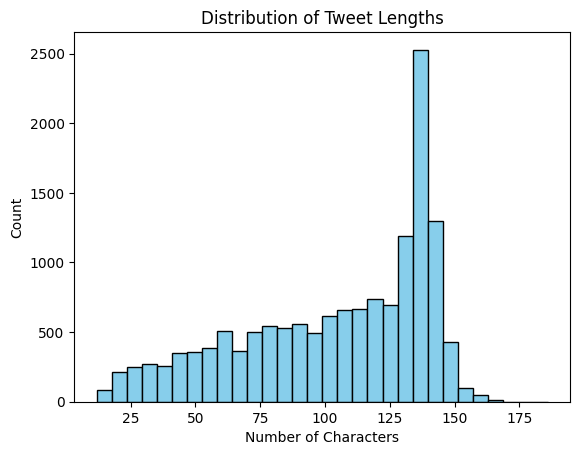

In [13]:
# Length of the tweets in characters
text_length = data["text"].str.len()

# Create the histogram
plt.hist(text_length, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')

# Save
plt.savefig('plots/text_length_histogram.png')

In [14]:
# Just an example to calculate the number of characters
t = data["text"][0]
print(t)
print(len(t))

@VirginAmerica What @dhepburn said.
35


In [15]:
# Most frequent words
# all tweets in one large string, lowercase everything, and split into words
all_words = ' '.join(data['text']).lower().split()
# Get the frequency of each word
word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']) # to dataframe
word_freq_df.sort_values(by="Frequency", ascending=False)

,Word,Frequency
8,to,8590
9,the,6034
12,i,5351
37,a,4461
48,for,3964
...,...,...
26831,@jlhalldc,1
26830,"play,",1
26829,answers!,1
26828,3.30pm,1


In [16]:
# Airline balance
airline_counts= data["airline"].value_counts()
airline_counts

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

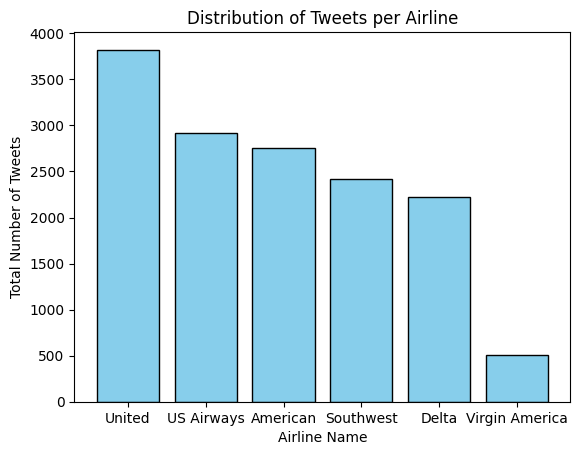

In [17]:
# Plot Airline balance
plt.bar(airline_counts.index, airline_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Tweets per Airline')
plt.xlabel('Airline Name')
plt.ylabel('Total Number of Tweets')

# Save
plt.savefig('plots/airline_class_balance.png')

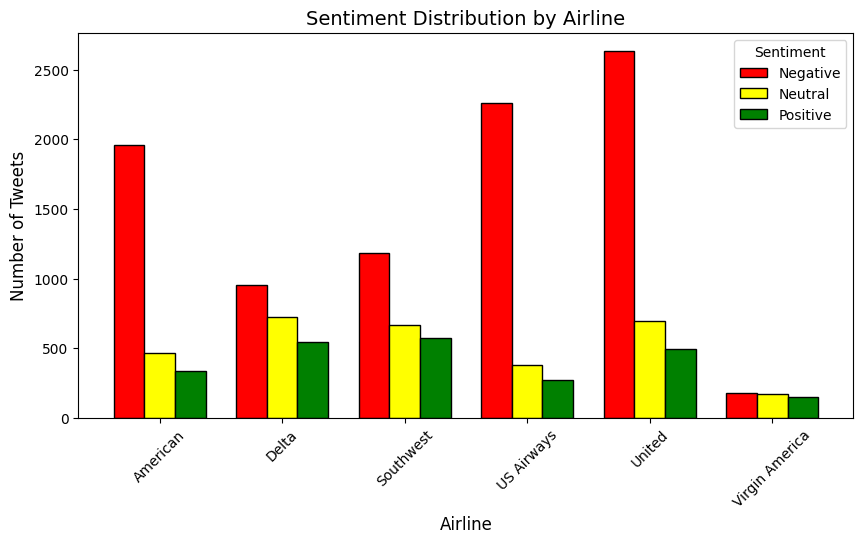

In [18]:
# Class balance per airline
# Group airline with sentiment
sentiment_data = data.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Figure settings
plt.figure(figsize=(10, 5))
airlines = sentiment_data.index
x = np.arange(len(airlines))  # The label locations
width = 0.25

# Plot sentiment group with colors
plt.bar(x - width, sentiment_data['negative'], width, label='Negative', color='red', edgecolor='black')
plt.bar(x, sentiment_data['neutral'], width, label='Neutral', color='yellow', edgecolor='black')
plt.bar(x + width, sentiment_data['positive'], width, label='Positive', color='green', edgecolor='black')

# Figure Layout
plt.title('Sentiment Distribution by Airline', fontsize=14)
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(x, airlines, rotation=45) # Set airline names as x-axis labels
plt.legend(title='Sentiment')

# Save
plt.savefig('plots/sentiment_per_airline.png')

## 2. Data preparation

tokenization, lowercasing, handling
punctuation, and potentially removing stop words (whenever is deemed necessary and
appropriate). Students should also consider how to handle unknown words (i.e., OOV –
Out of Vocabulary) and how to manage variable-length sequences.

In [19]:
# Initial cleaning
data = data.drop_duplicates()

# Drop irrelevant columns
columns_to_drop = ['tweet_coord', 'name', 'tweet_location', 'user_timezone', 'airline']
data_clean = data.drop(columns=columns_to_drop)

print("Shape after initial cleaning:", data_clean.shape)

Shape after initial cleaning: (14604, 10)


#### Text preprocessing

In [20]:
data_clean["text_clean"] = (
    data_clean["text"]
    .str.lower()
    .str.replace(r"http\S+|www\S+|https\S+", "", regex=True) # Remove URLs
    .str.replace(r"@\w+", "", regex=True)                    # Remove @mentions
    .str.replace(r"<[^>]+>", "", regex=True)                 # Remove HTML tags
    .str.replace(r"[^\w\s]", "", regex=True)                 # Remove punctuation
    .str.replace(r"\d+", "", regex=True)                     # Remove numbers
    .str.replace(r"\b[a-z]\b", "", regex=True)               # Remove one-letter words
    .str.replace(r"\s+", " ", regex=True)                    # Remove extra whitespaces 
    .str.strip()                                             # Trim leading/trailing spaces
)

# Check the results
data_clean[["text", "text_clean"]].head()

,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need to take another trip
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its really big bad thing about it


## 3. Modelling

• A baseline model using classical NLP techniques (e.g., TF-IDF + Logistic
Regression or Naive Bayes)

• A neural model such as an LSTM, CNN for text classification, or a Transformer-
based model like BERT.

In [21]:
X = data_clean["text_clean"]
y = data_clean["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Base model

In [23]:
logit_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

logit_params = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
}

nb_params = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__alpha': [0.1, 0.5, 1.0],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

def validate_model(X_train, y_train, model_pipeline, params, name, cv_model, metrics):
    grid = GridSearchCV(model_pipeline, params, cv=cv_model, scoring=metrics, refit='f1_macro', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    print(f"\n{name}:")
    print(f"  Best params: {grid.best_params_}")
    for metric in metrics:
        best_idx = grid.best_index_
        mean = grid.cv_results_[f'mean_test_{metric}'][best_idx]
        std = grid.cv_results_[f'std_test_{metric}'][best_idx]
        print(f"  {metric}: {mean:.4f} (+/- {std:.4f})")

    return grid

def show_conf_matrix(y_true, y_pred, name, labels=None):
    print(f"\n  Classification Report {name}:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'plots/confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.close()

logit_result = validate_model(X_train, y_train, logit_pipeline, logit_params, 'Logistic Regression', skf, metrics)
nb_result = validate_model(X_train, y_train, nb_pipeline, nb_params, 'Naive Bayes', skf, metrics)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Logistic Regression:
  Best params: {'clf__C': 1, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
  accuracy: 0.7916 (+/- 0.0101)
  f1_macro: 0.7400 (+/- 0.0114)
  precision_macro: 0.7349 (+/- 0.0114)
  recall_macro: 0.7464 (+/- 0.0118)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Naive Bayes:
  Best params: {'clf__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
  accuracy: 0.7757 (+/- 0.0042)
  f1_macro: 0.6810 (+/- 0.0065)
  precision_macro: 0.7686 (+/- 0.0076)
  recall_macro: 0.6419 (+/- 0.0070)


In [ ]:
y_pred_train_logit = logit_result.best_estimator_.predict(X_train)
show_conf_matrix(y_train, y_pred_train_logit, "Logistic Regression Train", ['negative', 'neutral', 'positive'])

y_pred_test_logit = logit_result.best_estimator_.predict(X_test)
show_conf_matrix(y_test, y_pred_test_logit, "Logistic Regression Test", ['negative', 'neutral', 'positive'])

y_pred_train_nb = nb_result.best_estimator_.predict(X_train)
show_conf_matrix(y_train, y_pred_train_nb, "Naive Bayes Train", ['negative', 'neutral', 'positive'])

y_pred_test_nb = nb_result.best_estimator_.predict(X_test)
show_conf_matrix(y_test, y_pred_test_nb, "Naive Bayes Test", ['negative', 'neutral', 'positive'])


  Classification Report Logistic Regression Train:
              precision    recall  f1-score   support

    negative       0.98      0.90      0.94      7327
     neutral       0.80      0.92      0.85      2473
    positive       0.87      0.96      0.91      1883

    accuracy                           0.92     11683
   macro avg       0.88      0.93      0.90     11683
weighted avg       0.92      0.92      0.92     11683


  Classification Report Logistic Regression Test:
              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      1832
     neutral       0.59      0.67      0.63       618
    positive       0.73      0.69      0.71       471

    accuracy                           0.79      2921
   macro avg       0.73      0.74      0.74      2921
weighted avg       0.80      0.79      0.79      2921



### Neural model

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [26]:
MIN_FREQ = 2 #How often does the word have to occur? 


def tokenize(text):
    return text.split()


token_counter = Counter(tok for text in X_train for tok in tokenize(text))
special_tokens = ["<PAD>", "<UNK>"]
vocab = special_tokens + [tok for tok, count in token_counter.items() if count >= MIN_FREQ] # only input word in vocab if frequency is higher than min.

word2idx = {word: idx for idx, word in enumerate(vocab)} 
idx2word = {idx: word for word, idx in word2idx.items()}
label2idx = {label: idx for idx, label in enumerate(sorted(y_train.unique()))} #label negative, neutral and positive with number
idx2label = {idx: label for label, idx in label2idx.items()}

PAD_IDX = word2idx["<PAD>"]
UNK_IDX = word2idx["<UNK>"] #OOV handling: words not in vocab (rare or unseen) map to this index

def encode_token(tok):
    return word2idx.get(tok, UNK_IDX)

print(f"Vocabulary size: {len(vocab)}")

print(f"Label mapping: {label2idx}")

Vocabulary size: 5110
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [27]:
def encode_dataset(texts, labels):
    encoded = []
    for text, label in zip(texts, labels):
        encoded.append({
            "input_ids": [encode_token(tok) for tok in tokenize(text)],
            "label": label2idx[label],
        })
    return encoded

def make_collate_fn(pad_idx):
    def collate_fn(batch):
        max_len = max(len(item["input_ids"]) for item in batch)
        input_ids, labels = [], []
        for item in batch:
            pad_len = max_len - len(item["input_ids"])
            input_ids.append(item["input_ids"] + [pad_idx] * pad_len)
            labels.append(item["label"])
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }
    return collate_fn

BATCH_SIZE = 64
collate_fn = make_collate_fn(PAD_IDX)

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

train_ds = encode_dataset(X_train_nn, y_train_nn)
val_ds = encode_dataset(X_val_nn, y_val_nn)
test_ds = encode_dataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

batch = next(iter(train_loader))
print("Batch shapes:")
print("  input_ids:", tuple(batch["input_ids"].shape))
print("  labels:", tuple(batch["labels"].shape))

Batch shapes:
  input_ids: (64, 25)
  labels: (64,)


### Initialise LSTM

In [28]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim // 2,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        
        mask = (input_ids != PAD_IDX).unsqueeze(-1).float() #need one vector for the whole tweet instead, so take average of all non-padded outputs. 1 for real tokens, 0 for padding
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        x = self.dropout(x)
        return self.classifier(x)

In [29]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids)
        loss = criterion(logits, labels)
        total_loss += loss.item() * input_ids.size(0)

        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=-1).cpu().tolist())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }

#### Hyperparameter tuning

In [30]:
param_grid = {
    'embed_dim': [50, 100],
    'hidden_dim': [64, 128],
    'lr': [1e-3, 5e-4],
    'dropout': [0.3, 0.5],
}

EPOCHS = 10
best_f1 = 0
best_params = None
best_model_state = None

combinations = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combinations)}\n")

class_counts = y_train_nn.value_counts().sort_index()
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.sum()

for embed_dim, hidden_dim, lr, dropout in combinations:
    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_labels=len(label2idx),
        pad_idx=PAD_IDX,
        dropout=dropout,
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(1, EPOCHS + 1):
        train_one_epoch(model, train_loader, optimiser, criterion)
    
    val_metrics = evaluate_model(model, val_loader, criterion)
    macro_f1 = val_metrics['macro_f1']
    
    print(f"embed={embed_dim}, hidden={hidden_dim}, lr={lr}, dropout={dropout} | val Macro-F1: {macro_f1:.4f}")
    
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_params = {'embed_dim': embed_dim, 'hidden_dim': hidden_dim, 'lr': lr, 'dropout': dropout}
        best_model_state = model.state_dict()

print(f"\nBest params: {best_params}")
print(f"Best val F1 macro: {best_f1:.4f}")

Total combinations: 16

embed=50, hidden=64, lr=0.001, dropout=0.3 | val Macro-F1: 0.7181
embed=50, hidden=64, lr=0.001, dropout=0.5 | val Macro-F1: 0.6962
embed=50, hidden=64, lr=0.0005, dropout=0.3 | val Macro-F1: 0.6838
embed=50, hidden=64, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6773
embed=50, hidden=128, lr=0.001, dropout=0.3 | val Macro-F1: 0.7137
embed=50, hidden=128, lr=0.001, dropout=0.5 | val Macro-F1: 0.7176
embed=50, hidden=128, lr=0.0005, dropout=0.3 | val Macro-F1: 0.7279
embed=50, hidden=128, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6874
embed=100, hidden=64, lr=0.001, dropout=0.3 | val Macro-F1: 0.7222
embed=100, hidden=64, lr=0.001, dropout=0.5 | val Macro-F1: 0.7009
embed=100, hidden=64, lr=0.0005, dropout=0.3 | val Macro-F1: 0.7016
embed=100, hidden=64, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6909
embed=100, hidden=128, lr=0.001, dropout=0.3 | val Macro-F1: 0.7145
embed=100, hidden=128, lr=0.001, dropout=0.5 | val Macro-F1: 0.7148
embed=100, hidden=128, lr=0.0005, 

Total combinations: 16

embed=50, hidden=64, lr=0.001, dropout=0.3 | val Macro-F1: 0.7181
embed=50, hidden=64, lr=0.001, dropout=0.5 | val Macro-F1: 0.6962
embed=50, hidden=64, lr=0.0005, dropout=0.3 | val Macro-F1: 0.6838
embed=50, hidden=64, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6773
embed=50, hidden=128, lr=0.001, dropout=0.3 | val Macro-F1: 0.7137
embed=50, hidden=128, lr=0.001, dropout=0.5 | val Macro-F1: 0.7176
embed=50, hidden=128, lr=0.0005, dropout=0.3 | val Macro-F1: 0.7279
embed=50, hidden=128, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6874
embed=100, hidden=64, lr=0.001, dropout=0.3 | val Macro-F1: 0.7222
embed=100, hidden=64, lr=0.001, dropout=0.5 | val Macro-F1: 0.7009
embed=100, hidden=64, lr=0.0005, dropout=0.3 | val Macro-F1: 0.7016
embed=100, hidden=64, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6909
embed=100, hidden=128, lr=0.001, dropout=0.3 | val Macro-F1: 0.7145
embed=100, hidden=128, lr=0.001, dropout=0.5 | val Macro-F1: 0.7148
embed=100, hidden=128, lr=0.0005, dropout=0.3 | val Macro-F1: 0.7080
embed=100, hidden=128, lr=0.0005, dropout=0.5 | val Macro-F1: 0.6979

Best params: {'embed_dim': 50, 'hidden_dim': 128, 'lr': 0.0005, 'dropout': 0.3}
Best val F1 macro: 0.7279

#### Final evaluation

In [39]:
best_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=best_params['embed_dim'],
    hidden_dim=best_params['hidden_dim'],
    num_labels=len(label2idx),
    pad_idx=PAD_IDX,
    dropout=best_params['dropout']).to(device)

best_model.load_state_dict(best_model_state)

# Create full train loader
full_train_ds = encode_dataset(X_train, y_train)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Evaluate on full train and test
full_train_metrics = evaluate_model(best_model, full_train_loader, criterion)
test_metrics = evaluate_model(best_model, test_loader, criterion)

y_true_train = [idx2label[idx] for idx in full_train_metrics["y_true"]]
y_pred_train = [idx2label[idx] for idx in full_train_metrics["y_pred"]]
show_conf_matrix(y_true_train, y_pred_train, "BiLSTM Train", ['negative', 'neutral', 'positive'])

y_true_test = [idx2label[idx] for idx in test_metrics["y_true"]]
y_pred_test = [idx2label[idx] for idx in test_metrics["y_pred"]]
show_conf_matrix(y_true_test, y_pred_test, "BiLSTM Test", ['negative', 'neutral', 'positive'])


  Classification Report BiLSTM Train:
              precision    recall  f1-score   support

    negative       0.96      0.83      0.89      7327
     neutral       0.66      0.83      0.73      2473
    positive       0.77      0.89      0.82      1883

    accuracy                           0.84     11683
   macro avg       0.79      0.85      0.82     11683
weighted avg       0.86      0.84      0.85     11683


  Classification Report BiLSTM Test:
              precision    recall  f1-score   support

    negative       0.89      0.76      0.82      1832
     neutral       0.54      0.71      0.61       618
    positive       0.61      0.69      0.65       471

    accuracy                           0.74      2921
   macro avg       0.68      0.72      0.70      2921
weighted avg       0.77      0.74      0.75      2921



## 4. Evaluation

The models must be evaluated using metrics such as accuracy, precision, recall, and F1-
score. Students should also include a confusion matrix and perform a qualitative analysis
of misclassified examples.

## X. Qualitative Error Analysis

In [40]:
# Create a clean test metadata table
test_meta = pd.DataFrame({
    "original_text": data.loc[X_test.index, "text"],
    "clean_text": data_clean.loc[X_test.index, "text_clean"],
    "true_label": y_test
})

# Add extra metadata from the original dataframe
test_meta["airline"] = data.loc[X_test.index, "airline"]
test_meta["negativereason"] = data.loc[X_test.index, "negativereason"]

print("Test metadata shape:", test_meta.shape)
display(test_meta.head())

Test metadata shape: (2921, 5)


,original_text,clean_text,true_label,airline,negativereason
10909,@USAirways call Gate D9 in CLT and get me on t...,call gate in clt and get me on this flight,neutral,US Airways,NaN
2537,"@united I appreciate the immediate offer, but ...",appreciate the immediate offer but suspect it ...,negative,United,Customer Service Issue
3002,@united Will you be issuing an exception polic...,will you be issuing an exception policy for de...,neutral,United,NaN
4818,@SouthwestAir Thanks for helping my mom after ...,thanks for helping my mom after wouldnt let he...,positive,Southwest,NaN
3687,@united have reported it. Still in Istanbul a...,have reported it still in istanbul at the mome...,positive,United,NaN


In [41]:
# Logistic Regression predictions + error table
best_logit = logit_result.best_estimator_
y_pred_logit = best_logit.predict(X_test)

logit_results = test_meta.copy()
logit_results["pred_label"] = y_pred_logit
logit_results["correct"] = logit_results["true_label"] == logit_results["pred_label"]
logit_results["confusion_pair"] = logit_results["true_label"] + " -> " + logit_results["pred_label"]

logit_errors = logit_results[logit_results["correct"] == False].copy()

print("\nLOGISTIC REGRESSION CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_logit))

print("Logistic Regression - number of errors:", len(logit_errors))
print("\nLogistic Regression - most common confusion pairs:")
print(logit_errors["confusion_pair"].value_counts())


LOGISTIC REGRESSION CLASSIFICATION REPORT

              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      1832
     neutral       0.59      0.67      0.63       618
    positive       0.73      0.69      0.71       471

    accuracy                           0.79      2921
   macro avg       0.73      0.74      0.74      2921
weighted avg       0.80      0.79      0.79      2921

Logistic Regression - number of errors: 617

Logistic Regression - most common confusion pairs:
confusion_pair
negative -> neutral     206
neutral -> negative     146
positive -> neutral      78
positive -> negative     66
negative -> positive     64
neutral -> positive      57
Name: count, dtype: int64


In [42]:
# Naive Bayes predictions + error table
best_nb = nb_result.best_estimator_
y_pred_nb = best_nb.predict(X_test)

nb_results = test_meta.copy()
nb_results["pred_label"] = y_pred_nb
nb_results["correct"] = nb_results["true_label"] == nb_results["pred_label"]
nb_results["confusion_pair"] = nb_results["true_label"] + " -> " + nb_results["pred_label"]

nb_errors = nb_results[nb_results["correct"] == False].copy()

print("\nNAIVE BAYES CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred_nb))

print("Naive Bayes - number of errors:", len(nb_errors))
print("\nNaive Bayes - most common confusion pairs:")
print(nb_errors["confusion_pair"].value_counts())


NAIVE BAYES CLASSIFICATION REPORT

              precision    recall  f1-score   support

    negative       0.78      0.95      0.86      1832
     neutral       0.69      0.41      0.52       618
    positive       0.81      0.56      0.66       471

    accuracy                           0.77      2921
   macro avg       0.76      0.64      0.68      2921
weighted avg       0.77      0.77      0.76      2921

Naive Bayes - number of errors: 659

Naive Bayes - most common confusion pairs:
confusion_pair
neutral -> negative     327
positive -> negative    154
negative -> neutral      63
positive -> neutral      52
neutral -> positive      36
negative -> positive     27
Name: count, dtype: int64


In [43]:
# BiLSTM predictions + error table
# test_metrics contains integer labels, so convert them back to strings
y_true_bilstm = [idx2label[i] for i in test_metrics["y_true"]]
y_pred_bilstm = [idx2label[i] for i in test_metrics["y_pred"]]

bilstm_results = test_meta.copy()
bilstm_results["pred_label"] = y_pred_bilstm
bilstm_results["correct"] = bilstm_results["true_label"] == bilstm_results["pred_label"]
bilstm_results["confusion_pair"] = bilstm_results["true_label"] + " -> " + bilstm_results["pred_label"]

bilstm_errors = bilstm_results[bilstm_results["correct"] == False].copy()

print("\nBILSTM CLASSIFICATION REPORT\n")
print(classification_report(y_true_bilstm, y_pred_bilstm))

print("BiLSTM - number of errors:", len(bilstm_errors))
print("\nBiLSTM - most common confusion pairs:")
print(bilstm_errors["confusion_pair"].value_counts())


BILSTM CLASSIFICATION REPORT

              precision    recall  f1-score   support

    negative       0.89      0.76      0.82      1832
     neutral       0.54      0.71      0.61       618
    positive       0.61      0.69      0.65       471

    accuracy                           0.74      2921
   macro avg       0.68      0.72      0.70      2921
weighted avg       0.77      0.74      0.75      2921

BiLSTM - number of errors: 753

BiLSTM - most common confusion pairs:
confusion_pair
negative -> neutral     301
negative -> positive    131
neutral -> negative     103
positive -> neutral      82
neutral -> positive      74
positive -> negative     62
Name: count, dtype: int64


In [44]:
# Function to print representative errors
def show_errors(errors_df, model_name, n_per_pair=3):
    print("\n" + "="*80)
    print(model_name)
    print("="*80)

    for pair in errors_df["confusion_pair"].value_counts().index:
        print(f"\n--- {pair} ---")
        subset = errors_df[errors_df["confusion_pair"] == pair].head(n_per_pair)

        for _, row in subset.iterrows():
            print("\nTweet:", row["original_text"])
            print("Cleaned:", row["clean_text"])
            print("Airline:", row["airline"])
            print("Negative reason:", row["negativereason"])
            print("True:", row["true_label"])
            print("Predicted:", row["pred_label"])
            print("-" * 60)

In [45]:
# Show representative mistakes
show_errors(logit_errors, "Logistic Regression Errors", n_per_pair=3)
show_errors(nb_errors, "Naive Bayes Errors", n_per_pair=3)
show_errors(bilstm_errors, "BiLSTM Errors", n_per_pair=3)


Logistic Regression Errors

--- negative -> neutral ---

Tweet: @USAirways I booked a flight yesterday but didnt receive an email confirmation and I my dividends number isn't registering. Please help.
Cleaned: booked flight yesterday but didnt receive an email confirmation and my dividends number isnt registering please help
Airline: US Airways
Negative reason: Flight Booking Problems
True: negative
Predicted: neutral
------------------------------------------------------------

Tweet: @JetBlue where is it coming from? I thought Tampa?
Cleaned: where is it coming from thought tampa
Airline: Delta
Negative reason: Late Flight
True: negative
Predicted: neutral
------------------------------------------------------------

Tweet: @united can you tell me how to file a claim for clothing that had to be purchased?
Cleaned: can you tell me how to file claim for clothing that had to be purchased
Airline: United
Negative reason: Lost Luggage
True: negative
Predicted: neutral
-------------------

In [52]:
qual_sample = pd.concat([
    nb_errors.assign(model="Naive Bayes"),
    logit_errors.assign(model="Logistic Regression"),
    bilstm_errors.assign(model="BiLSTM")
], axis=0)

qual_sample = pd.concat([
    qual_sample[qual_sample["model"] == m].sample(n=min(20, len(qual_sample[qual_sample["model"] == m])), random_state=42)
    for m in qual_sample["model"].unique()
]).reset_index(drop=False).rename(columns={"index": "original_index"})

qual_sample["error_category"] = ""
qual_sample["notes"] = ""

pd.set_option("display.max_colwidth", None)
print("\nSample for manual qualitative analysis:")
display(qual_sample)


Sample for manual qualitative analysis:


,original_index,original_text,clean_text,true_label,airline,negativereason,pred_label,correct,confusion_pair,model,error_category,notes
0,3552,@united flight...gotta make this connector,flightgotta make this connector,neutral,United,NaN,negative,False,neutral -> negative,Naive Bayes,,
1,8954,@JetBlue to offer service from Daytona Beach to New York - Albany Business Review http://t.co/dUhBJ41jHx,to offer service from daytona beach to new york albany business review,positive,Delta,NaN,neutral,False,positive -> neutral,Naive Bayes,,
2,5766,@SouthwestAir LOVE IMAGINE DRAGONS SO MUCH I EOULD DIE IF I GOT TICKETS,love imagine dragons so much eould die if got tickets,positive,Southwest,NaN,neutral,False,positive -> neutral,Naive Bayes,,
3,7589,"@JetBlue yup we know, not your fault, just not ideal sittin for over an hour but as always your staff is great!",yup we know not your fault just not ideal sittin for over an hour but as always your staff is great,positive,Delta,NaN,negative,False,positive -> negative,Naive Bayes,,
4,7275,"@JetBlue ha ha! Can I get a wake up call at boarding time please? Large coffee, extralight extra sweet please!",ha ha can get wake up call at boarding time please large coffee extralight extra sweet please,positive,Delta,NaN,neutral,False,positive -> neutral,Naive Bayes,,
5,12311,@AmericanAir Connection is US2065,connection is us,neutral,American,NaN,negative,False,neutral -> negative,Naive Bayes,,
6,3979,"@united Great, thank you!! I'll send it now.",great thank you ill send it now,neutral,United,NaN,positive,False,neutral -> positive,Naive Bayes,,
7,4607,@SouthwestAir telling my Fam in Vegas now. :),telling my fam in vegas now,positive,Southwest,NaN,neutral,False,positive -> neutral,Naive Bayes,,
8,13726,@AmericanAir thanks for following up. I think it's fair to refund the ticket price and the two one way rental cars I had to buy.,thanks for following up think its fair to refund the ticket price and the two one way rental cars had to buy,positive,American,NaN,negative,False,positive -> negative,Naive Bayes,,
9,2130,@united What a really GREAT &amp; FLATTERING story about you! You should be very proud :) http://t.co/7br5t5QCXk (via @ParachuteGuy),what really great amp flattering story about you you should be very proud via,positive,United,NaN,negative,False,positive -> negative,Naive Bayes,,


In [ ]:
# Assign all 60 errors to a category (out of six categories) and add a note about why we think the error could have occured. 
# Via this way we try to recognize patterns in the errors ourselves. 
qual_sample_annotated = qual_sample.copy()

annotations = {
    # BILSTM
    0: ("mixed_or_ambiguous_sentiment",
       "The tweet refers to an earlier problem ('apology') but also expresses a positive resolution ('accepted', 'customerserviceWIN'), so it contains mixed sentiment cues."),
    1: ("neutral_request_or_information",
        "Mainly a practical request about changing a frequent-flyer number, not a complaint."),
    2: ("neutral_request_or_information",
        "The tweet does not express a clear opinion about the airline. The negative prediction may be caused by the rhetorical question ('who doesn't have a good time')."),
    3: ("implicit_negative_or_complaint",
        "Complaint about baggage policy and inconsistency, but phrased as a question rather than direct negative opinion."),
    4: ("neutral_request_or_information",
        "The tweet contains polite gratitude ('Thank you', 'appreciate'), but it functions mainly as a conversational response rather than a clear positive evaluation of the airline."),
    5: ("implicit_negative_or_complaint",
        "Complaint about inability to log in, but framed as a question asking whether there is an issue."),
    6: ("implicit_negative_or_complaint",
        "Negative service issue is described through facts ('flight has disappeared', 'Help please') rather than strong emotional words."),
    7: ("mixed_or_ambiguous_sentiment",
        "Contains both gratitude ('Thank you for credits') and dissatisfaction ('submitted complaints'), creating mixed signals."),
    8: ("implicit_negative_or_complaint",
        "Problem with TSA pre-check on boarding pass is a service complaint, but phrased politely as a request for help."),
    9: ("implicit_negative_or_complaint",
        "Negative sentiment is clear ('treated so poorly'), but the model may underweight it because the tweet is descriptive rather than strongly emotional."),
    10: ("neutral_request_or_information",
         "This is mainly a personal update about catching the flight, not a clear opinion about the airline or its service."),
    11: ("implicit_negative_or_complaint",
         "Complaint about delay/backlog, but the language is short and directive rather than explicitly emotional."),
    12: ("implicit_negative_or_complaint",
         "Sarcastic or critical question ('can you define extra time?') expresses dissatisfaction indirectly."),
    13: ("preprocessing_or_context_loss",
         "Preprocessing merged 'city' and 'not' into 'citynot', which weakens the important negative cue 'not happy customer'. This likely made the complaint harder to classify correctly."),
    14: ("possible_label_noise_or_hard_case",
         "The tweet reads as negative because it criticizes the airline's delay explanation sarcastically. The true neutral label seems debatable."), 
    15: ("implicit_negative_or_complaint",
         "Complaint about lost luggage delivery, but expressed as a request to fix the problem rather than direct sentiment."),
    16: ("positive_but_informal_or_subtle",
         "Clearly promotional/positive message, but Twitter-specific phrasing and hashtags may make sentiment less obvious to the model."),
    17: ("neutral_request_or_information",
         "Mainly clarifies delivery instructions and asks the airline not to deliver, without explicit sentiment."),
    18: ("positive_but_informal_or_subtle",
         "Positive reassurance ('No worries') is brief and informal, which may weaken the positive signal."),
    19: ("possible_label_noise_or_hard_case",
         "Although the true label is neutral, the tweet expresses frustration about not being able to call and about seat availability. This makes it a borderline case between neutral service inquiry and negative complaint."), 
     # LOGISTIC REGRESSION
    20: ("implicit_negative_or_complaint",
         "Complaint about poor flight conditions, but begins with the misleading token 'amazing' and uses hashtag-based negativity."),
    21: ("implicit_negative_or_complaint",
         "Complaint about delay is phrased as a rhetorical question, which makes the negative sentiment less direct."),
    22: ("positive_but_informal_or_subtle",
         "Short positive encouragement ('Keep it up') lacks strong context, so it can look neutral."),
    23: ("possible_label_noise_or_hard_case",
         "The tweet is phrased as a neutral question about expected cancellations, but because it concerns a disruptive travel problem it may have been annotated as negative. This makes it a borderline case."), 
    24: ("mixed_or_ambiguous_sentiment",
         "Positive content about free drink coupons may be read sarcastically because of exaggeration ('over 30 coupons now')."),
    25: ("neutral_request_or_information",
         "Mostly factual follow-up about how to modify plans, not a clearly negative opinion."),
    26: ("implicit_negative_or_complaint",
         "Negative complaint uses polite wording ('thanks') that can make it appear positive."),
    27: ("implicit_negative_or_complaint",
         "Complaint about unfair upgrade behavior, but stated descriptively rather than with explicit emotion words."),
    28: ("implicit_negative_or_complaint",
         "The phrase 'will be great when you retire them' is negative in meaning but contains positive-looking words like 'great'."),
    29: ("neutral_request_or_information",
         "Short factual follow-up ('Just DMd you') with little sentiment content."),
    30: ("neutral_request_or_information",
         "This is more like a hopeful request than a positive review or complaint."),
    31: ("mixed_or_ambiguous_sentiment",
         "The tweet describes a stressful situation but ends positively ('made it', 'Tnx'), giving mixed cues."),
    32: ("preprocessing_or_context_loss",
         "Extremely short reply. After cleaning almost all useful context disappears, making sentiment hard to infer."),
    33: ("implicit_negative_or_complaint",
         "Complaint about lost luggage is expressed mostly through factual description and coordination details."),
    34: ("positive_but_informal_or_subtle",
         "Short positive praise ('That's classy') is informal and lacks stronger sentiment context."),
    35: ("preprocessing_or_context_loss",
         "Original positive cue likely depended partly on emoji/smiley, but cleaning removes that sentiment signal."),
    36: ("implicit_negative_or_complaint",
         "Complaint about broken support email is stated factually, which may make it look neutral."),
    37: ("positive_but_informal_or_subtle",
         "This looks like hopeful or supportive language toward the flight, but the sentiment is mild and context-dependent."),
    38: ("implicit_negative_or_complaint",
         "The tweet is clearly sarcastic. Although it contains the positive-looking word 'thx', it actually expresses frustration about being ignored."),
    39: ("implicit_negative_or_complaint",
         "Complaint about cancellations is phrased as a question asking whether the situation will change."),
     # NAIVE BAYES
    40: ("neutral_request_or_information",
         "Mainly expresses urgency about making a connection, not a direct negative opinion about the airline."),
    41: ("mixed_or_ambiguous_sentiment",
         "The tweet is overall positive, but includes a wish/complaint component about routes and another airline, creating mixed cues."),
    42: ("mixed_or_ambiguous_sentiment",
         "Contains explicit praise ('wonderful') but also mentions a malfunctioning tray table, producing mixed signals."),
    43: ("neutral_request_or_information",
         "Practical booking question about fares and miles, not a complaint."),
    44: ("preprocessing_or_context_loss",
         "Very short tweet with little standalone sentiment. Likely depends on missing external context."),
    45: ("positive_but_informal_or_subtle",
         "The tweet is clearly positive, but the praise is expressed through informal words ('Aww', 'cool', 'faves'). This suggests Naive Bayes struggles with casual positive language and may be biased toward negative predictions."), 
    46: ("neutral_request_or_information",
         "Question asking about complaint response time. Mentions a complaint but is itself informational."),
    47: ("neutral_request_or_information",
         "The tweet is a conversational observation that many people seem to be flying to Pittsburgh that weekend. It does not express a clear positive or negative opinion about the airline."), 
    48: ("neutral_request_or_information",
         "Mostly factual explanation about an e-voucher, without clear sentiment."),
    49: ("possible_label_noise_or_hard_case",
         "The true positive label is difficult to justify from the text alone. The tweet reads more like a neutral or playful remark than a clearly positive opinion about the airline."),
    50: ("positive_but_informal_or_subtle",
         "Strongly positive tweet ('awesome', 'Luv you guys'), but informal wording may confuse a simple model."),
    51: ("mixed_or_ambiguous_sentiment",
         "The tweet expresses frustration about having to use another airline, but also implies a positive preference for Southwest and asks them to add the route. It contains both negative and positive cues."),    
    52: ("neutral_request_or_information",
         "The tweet appears to mean 'I would love to go/fly to Fort Lauderdale, that would be cool.' It expresses a travel wish rather than a clear opinion about the airline."),
    53: ("preprocessing_or_context_loss",
         "The tweet appears to be incomplete and was likely intended as praise such as 'provided outstanding service'. Because the key word is unclear, the sentiment is difficult to determine reliably from the text alone."),
    54: ("neutral_request_or_information",
         "Mainly asking for clarification about a surcharge, not explicitly complaining."),
    55: ("preprocessing_or_context_loss",
         "Single-word reply ('done') contains almost no sentiment and depends heavily on prior conversation context."),
    56: ("neutral_request_or_information",
         "Simple request for route/timing information, not a clear complaint."),
    57: ("neutral_request_or_information",
         "This tweet mainly shares a news headline rather than expressing the user's own clear sentiment about the airline, so the positive label may be difficult for the model to detect."),
    58: ("positive_but_informal_or_subtle",
         "Strongly positive praise and thanks, but informal expression like 'kicked butt' may not be captured well by the model."),
    59: ("preprocessing_or_context_loss",
         "Very short reply ('try this') depends almost entirely on conversational context, so sentiment is hard to infer.")
}

for row_id, (category, note) in annotations.items():
    qual_sample_annotated.loc[row_id, "error_category"] = category
    qual_sample_annotated.loc[row_id, "notes"] = note
    
display(qual_sample_annotated)

# The whole file including categories and notes is saved as a CSV file
# Ik heb het dus voor de zekerheid opgeslagen ivm reproducibility. Als je hem nu rerund krijg je andere errors en is deze hele analyse "voor niks" geweest.
# Of ja het is alsnog nuttig en ik ga ook gwn het hoofdstuk schrijven met deze info, maar moeten even samen kijken hoe we dit op kunnen lossen. 

In [ ]:
# Create an overview of the amount of errors per category and per model.
category_summary = (
    qual_sample_annotated["error_category"]
    .value_counts()
    .rename_axis("error_category")
    .reset_index(name="count")
)

display(category_summary)

# Fix this:
category_by_model = pd.crosstab(
    qual_sample_annotated["model"],
    qual_sample_annotated["error_category"]
)

display(category_by_model)